In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8')

print("All libraries loaded successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Matplotlib is building the font cache; this may take a moment.


All libraries loaded successfully!
Pandas version: 2.3.3
NumPy version: 2.4.4


In [2]:
# Load the transaction data
print("Loading dataset... this may take 30-60 seconds")

df_transaction = pd.read_csv('../data/raw/train_transaction.csv')
df_identity = pd.read_csv('../data/raw/train_identity.csv')

print(f"Transaction data shape: {df_transaction.shape}")
print(f"Identity data shape: {df_identity.shape}")
print(f"\nTransaction columns: {df_transaction.shape[1]}")
print(f"Identity columns: {df_identity.shape[1]}")
print(f"\nTotal transactions: {df_transaction.shape[0]:,}")

Loading dataset... this may take 30-60 seconds
Transaction data shape: (590540, 394)
Identity data shape: (144233, 41)

Transaction columns: 394
Identity columns: 41

Total transactions: 590,540


Not Fraud (0): 569,877
Fraud (1):     20,663

Fraud rate: 3.50%
Class imbalance ratio: 28:1


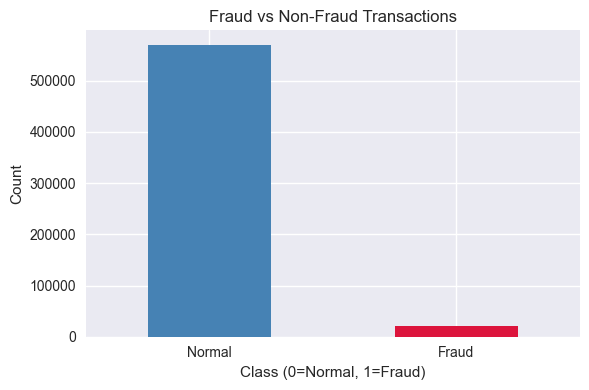

In [3]:
# Check class imbalance
fraud_count = df_transaction['isFraud'].value_counts()
fraud_rate = df_transaction['isFraud'].mean() * 100

print(f"Not Fraud (0): {fraud_count[0]:,}")
print(f"Fraud (1):     {fraud_count[1]:,}")
print(f"\nFraud rate: {fraud_rate:.2f}%")
print(f"Class imbalance ratio: {fraud_count[0]/fraud_count[1]:.0f}:1")

# Visualise
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
fraud_count.plot(kind='bar', ax=ax, color=['steelblue', 'crimson'])
ax.set_title('Fraud vs Non-Fraud Transactions')
ax.set_xlabel('Class (0=Normal, 1=Fraud)')
ax.set_ylabel('Count')
ax.set_xticklabels(['Normal', 'Fraud'], rotation=0)
plt.tight_layout()
plt.show()

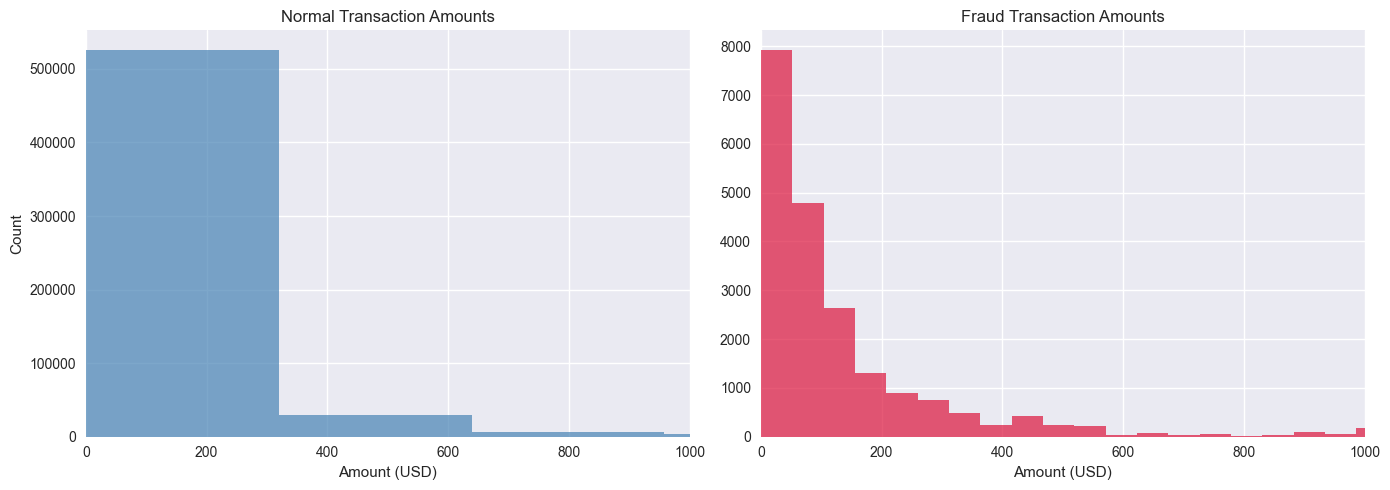

Normal - Mean: $134.51
Fraud  - Mean: $149.24


In [4]:
# Transaction amount analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal transactions
axes[0].hist(df_transaction[df_transaction['isFraud']==0]['TransactionAmt'], 
             bins=100, color='steelblue', alpha=0.7)
axes[0].set_title('Normal Transaction Amounts')
axes[0].set_xlabel('Amount (USD)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 1000)

# Fraud transactions
axes[1].hist(df_transaction[df_transaction['isFraud']==1]['TransactionAmt'], 
             bins=100, color='crimson', alpha=0.7)
axes[1].set_title('Fraud Transaction Amounts')
axes[1].set_xlabel('Amount (USD)')
axes[1].set_xlim(0, 1000)

plt.tight_layout()
plt.show()

print(f"Normal - Mean: ${df_transaction[df_transaction['isFraud']==0]['TransactionAmt'].mean():.2f}")
print(f"Fraud  - Mean: ${df_transaction[df_transaction['isFraud']==1]['TransactionAmt'].mean():.2f}")

In [5]:
# Missing value analysis
missing = df_transaction.isnull().sum()
missing_pct = (missing / len(df_transaction) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

# Show top 20 columns with most missing values
print("Top 20 columns with most missing values:")
print(missing_df[missing_df['missing_count'] > 0].head(20))

print(f"\nTotal columns with missing values: {(missing > 0).sum()}")
print(f"Total columns with >50% missing: {(missing_pct > 50).sum()}")

Top 20 columns with most missing values:
       missing_count  missing_pct
dist2         552913        93.63
D7            551623        93.41
D13           528588        89.51
D14           528353        89.47
D12           525823        89.04
D6            517353        87.61
D9            515614        87.31
D8            515614        87.31
V153          508595        86.12
V140          508595        86.12
V150          508589        86.12
V149          508595        86.12
V155          508595        86.12
V147          508595        86.12
V146          508595        86.12
V145          508589        86.12
V144          508589        86.12
V143          508589        86.12
V142          508595        86.12
V141          508595        86.12

Total columns with missing values: 374
Total columns with >50% missing: 174


In [6]:
# Basic dataset overview
print("=== DATASET SUMMARY ===")
print(f"\nTotal transactions: {len(df_transaction):,}")
print(f"Fraud transactions: {df_transaction['isFraud'].sum():,}")
print(f"Fraud rate: {df_transaction['isFraud'].mean()*100:.2f}%")
print(f"Class imbalance: {(1-df_transaction['isFraud'].mean())/df_transaction['isFraud'].mean():.0f}:1")
print(f"\nTotal features: {df_transaction.shape[1]}")
print(f"Features with missing values: 374")
print(f"Features with >50% missing: 174")
print(f"\nTransaction amount range: ${df_transaction['TransactionAmt'].min():.2f} - ${df_transaction['TransactionAmt'].max():,.2f}")
print(f"Mean fraud amount: $149.24")
print(f"Mean normal amount: $134.51")

print("\n=== KEY FINDINGS FOR EDA ===")
print("1. Severe class imbalance (28:1) - must use AUC-ROC not accuracy")
print("2. 174 features >50% missing - need careful imputation strategy")
print("3. Fraud transactions slightly higher value on average")
print("4. Both distributions heavily right-skewed - consider log transform")


=== DATASET SUMMARY ===

Total transactions: 590,540
Fraud transactions: 20,663
Fraud rate: 3.50%
Class imbalance: 28:1

Total features: 394
Features with missing values: 374
Features with >50% missing: 174

Transaction amount range: $0.25 - $31,937.39
Mean fraud amount: $149.24
Mean normal amount: $134.51

=== KEY FINDINGS FOR EDA ===
1. Severe class imbalance (28:1) - must use AUC-ROC not accuracy
2. 174 features >50% missing - need careful imputation strategy
3. Fraud transactions slightly higher value on average
4. Both distributions heavily right-skewed - consider log transform
